## Data Preprocessing

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
# A. set tickers as index
df = pd.read_csv("pvCLCL_matrix.csv")
df = df.set_index(df.columns[0])
df.head()

,2000-01-03,2000-01-04,2000-01-05,2000-01-06,2000-01-07,2000-01-10,2000-01-11,2000-01-12,2000-01-13,2000-01-14,...,2021-12-17,2021-12-20,2021-12-21,2021-12-22,2021-12-23,2021-12-27,2021-12-28,2021-12-29,2021-12-30,2021-12-31
ticker,,,,,,,,,,,,,,,,,,,,,
AA,-0.024849,0.004633,0.057648,-0.013081,-0.002946,-0.002954,-0.005926,-0.008942,-0.018045,-0.019908,...,0.021677,-0.011539,0.06929,0.044374,0.000843,0.007918,-0.010697,0.007434,-0.007043,0.006249
AAA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.000399,-0.000200,0.00040,-0.000998,0.000000,0.000000,0.000400,0.000109,0.000000,0.000400
AAC,0.028169,-0.027397,0.000000,0.014085,0.013889,-0.013699,0.000000,0.027778,0.000000,0.027027,...,0.001023,-0.002045,0.00000,-0.001025,0.000000,-0.001026,0.000000,0.000000,0.000000,0.000000
AAG,-0.027778,-0.010714,0.003610,-0.003597,0.003610,0.007194,0.000000,0.003571,0.000000,-0.039146,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AAI,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
# B. standardize time dtype
df.columns = pd.to_datetime(df.columns, format="%Y-%m-%d")
df.head()

,2000-01-03,2000-01-04,2000-01-05,2000-01-06,2000-01-07,2000-01-10,2000-01-11,2000-01-12,2000-01-13,2000-01-14,...,2021-12-17,2021-12-20,2021-12-21,2021-12-22,2021-12-23,2021-12-27,2021-12-28,2021-12-29,2021-12-30,2021-12-31
ticker,,,,,,,,,,,,,,,,,,,,,
AA,-0.024849,0.004633,0.057648,-0.013081,-0.002946,-0.002954,-0.005926,-0.008942,-0.018045,-0.019908,...,0.021677,-0.011539,0.06929,0.044374,0.000843,0.007918,-0.010697,0.007434,-0.007043,0.006249
AAA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.000399,-0.000200,0.00040,-0.000998,0.000000,0.000000,0.000400,0.000109,0.000000,0.000400
AAC,0.028169,-0.027397,0.000000,0.014085,0.013889,-0.013699,0.000000,0.027778,0.000000,0.027027,...,0.001023,-0.002045,0.00000,-0.001025,0.000000,-0.001026,0.000000,0.000000,0.000000,0.000000
AAG,-0.027778,-0.010714,0.003610,-0.003597,0.003610,0.007194,0.000000,0.003571,0.000000,-0.039146,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AAI,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
# C. coerce numerical dtypes
df = df.apply(pd.to_numeric, errors="coerce")
df.head()

,2000-01-03,2000-01-04,2000-01-05,2000-01-06,2000-01-07,2000-01-10,2000-01-11,2000-01-12,2000-01-13,2000-01-14,...,2021-12-17,2021-12-20,2021-12-21,2021-12-22,2021-12-23,2021-12-27,2021-12-28,2021-12-29,2021-12-30,2021-12-31
ticker,,,,,,,,,,,,,,,,,,,,,
AA,-0.024849,0.004633,0.057648,-0.013081,-0.002946,-0.002954,-0.005926,-0.008942,-0.018045,-0.019908,...,0.021677,-0.011539,0.06929,0.044374,0.000843,0.007918,-0.010697,0.007434,-0.007043,0.006249
AAA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.000399,-0.000200,0.00040,-0.000998,0.000000,0.000000,0.000400,0.000109,0.000000,0.000400
AAC,0.028169,-0.027397,0.000000,0.014085,0.013889,-0.013699,0.000000,0.027778,0.000000,0.027027,...,0.001023,-0.002045,0.00000,-0.001025,0.000000,-0.001026,0.000000,0.000000,0.000000,0.000000
AAG,-0.027778,-0.010714,0.003610,-0.003597,0.003610,0.007194,0.000000,0.003571,0.000000,-0.039146,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AAI,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
# D. na check
df.isna().sum().sort_values(ascending=False).head(10)

2021-12-28    3360
2021-12-29    3359
2021-12-15    3356
2021-12-27    3356
2021-12-23    3356
2021-12-20    3356
2021-12-14    3356
2021-12-17    3355
2021-12-21    3355
2021-12-22    3354
dtype: int64

In [15]:
df.isna().sum(axis=1).sort_values(ascending=False).head(10)

ticker
LOG     5530
ERP     5529
SMGS    5528
MNES    5524
PZX     5522
MTI     5522
PMB     5522
PZM     5522
BRH     5521
UNII    5520
dtype: int64

In [41]:
def drop_assets_by_missing_ratio(
    df: pd.DataFrame,
    max_missing_ratio: float = 0.8,
):
    """
    Drop assets (rows) with missing ratio > max_missing_ratio.

    df: index = ticker, columns = dates
    max_missing_ratio: e.g. 0.8 means drop if >80% NA
    """
    missing_ratio = df.isna().mean(axis=1)
    keep = missing_ratio <= max_missing_ratio
    return df.loc[keep]

df_filtered = drop_assets_by_missing_ratio(df, max_missing_ratio=0.6)
print(df.shape, "→", df_filtered.shape)


(6089, 5531) → (3170, 5531)


In [42]:
df_filtered.isna().sum(axis=1).sort_values(ascending=False).head(10)

ticker
BLN    3318
SOA    3317
RNO    3316
TEU    3316
NAP    3314
VET    3313
LDG    3313
IKN    3312
JAG    3312
EXE    3312
dtype: int64

In [45]:
# df_filtered.to_csv("pvCLCL_cleaned.csv")

In [47]:
# # E. Optional: winsorization
# df_filtered = df_filtered.clip(lower=df_filtered.quantile(0.001),
#              upper=df_filtered.quantile(0.999),
#              axis=1)
# df_filtered.describe()

## EDA

In [50]:
# A. Basic Return Distribution (all stocks, all dates)
df_filtered.stack().describe(percentiles=[0.01, 0.05, 0.95, 0.99])

count    1.336022e+07
mean     5.693487e-04
std      2.902998e-02
min     -9.050890e-01
1%      -7.611000e-02
5%      -3.615300e-02
50%      0.000000e+00
95%      3.703700e-02
99%      8.176100e-02
max      1.236515e+01
dtype: float64

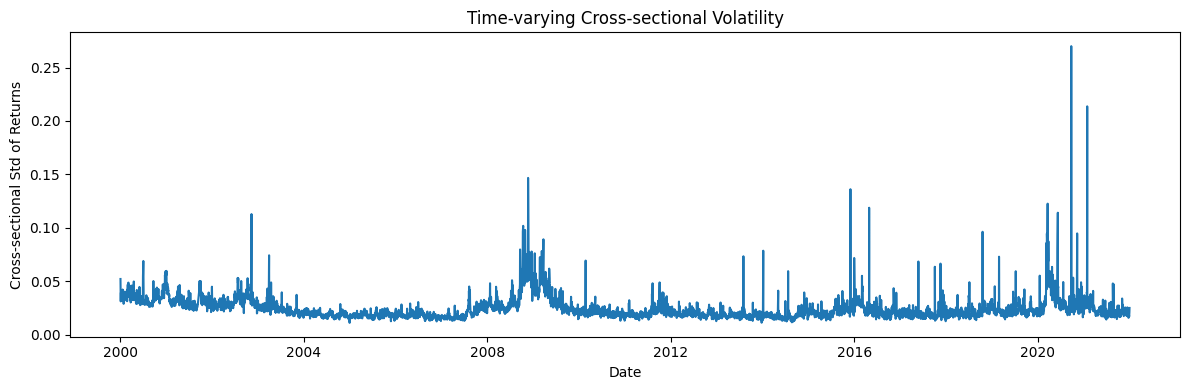

In [54]:
# B. Time-varying Cross-sectional Volatility
cross_vol = df_filtered.std(axis=0)

plt.figure(figsize=(12, 4))
plt.plot(cross_vol.index, cross_vol.values)
plt.title("Time-varying Cross-sectional Volatility")
plt.xlabel("Date")
plt.ylabel("Cross-sectional Std of Returns")
plt.tight_layout()
plt.show()

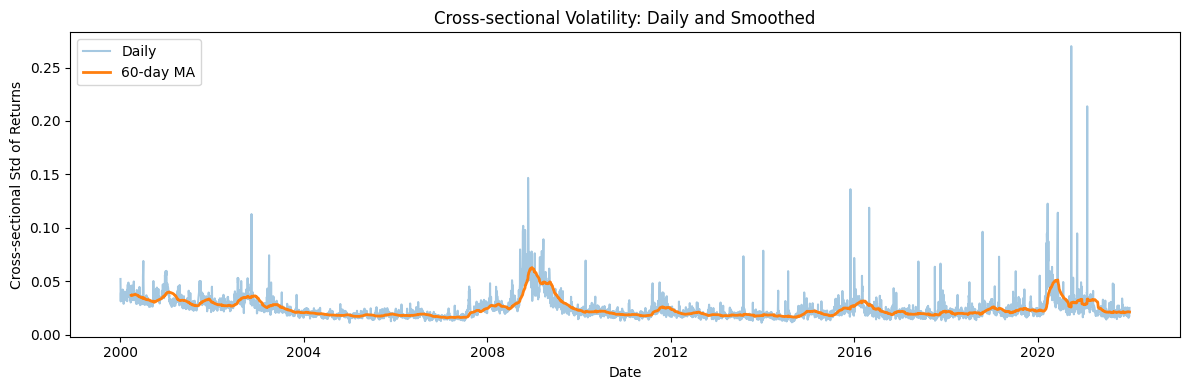

In [56]:
smooth = cross_vol.rolling(60).mean()

plt.figure(figsize=(12, 4))
plt.plot(cross_vol.index, cross_vol.values, alpha=0.4, label="Daily")
plt.plot(smooth.index, smooth.values, linewidth=2, label="60-day MA")
plt.title("Cross-sectional Volatility: Daily and Smoothed")
plt.xlabel("Date")
plt.ylabel("Cross-sectional Std of Returns")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# C. Eigenspectrum of covariance
import numpy as np

window = df.loc[:, "2007-01-01":"2007-12-31"]
Sigma = np.cov(window.values)
eigs = np.linalg.eigvalsh(Sigma)

In [ ]:
# D. Covariance Instablity
def cov_window(t0, T=60):
    return np.cov(df.iloc[:, t0-T:t0].values)